## Import Statements

In [1]:
import torch
import torch_geometric
from torch_geometric import utils
from torch_geometric.nn import SAGEConv
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

from scipy.sparse import coo_matrix
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from torch_geometric.explain import Explainer, GNNExplainer
from sklearn.metrics import roc_auc_score, precision_recall_curve, f1_score

## Load in Hi-C Matrices and node information, build graph

In [2]:
ec_hic = np.load('data/ec_adj_mat_t25.npy')
hsr_hic = np.load('data/hsr_adj_mat_t25.npy')

ec_df = pd.read_csv('data/ec_cleaned.csv')
hsr_df = pd.read_csv('data/hsr_cleaned.csv')

hsr_feats = torch.tensor(hsr_df[['read_count', 'total_genes']].to_numpy())
hsr_labels = torch.zeros(hsr_feats.shape[0])

ec_feats = torch.tensor(ec_df[['read_count', 'total_genes']].to_numpy())
ec_labels = torch.ones(ec_feats.shape[0])

def hic_to_sparse(hic_mat):
    adj_mat = np.triu(hic_mat)
    sparse_adj = coo_matrix(adj_mat)

    return utils.from_scipy_sparse_matrix(sparse_adj)

hsr_edge_index, hsr_edge_attr = hic_to_sparse(hsr_hic)
hsr_graph = torch_geometric.data.Data(edge_index = hsr_edge_index, edge_attr = hsr_edge_attr, x = hsr_feats, y = hsr_labels)

ec_edge_index, ec_edge_attr = hic_to_sparse(ec_hic)
ec_graph = torch_geometric.data.Data(edge_index = ec_edge_index, edge_attr = ec_edge_attr, x = ec_feats, y = ec_labels)

x = torch.cat([ec_feats, hsr_feats], dim=0)
hsr_edge_index = hsr_edge_index + ec_labels.shape[0]
edge_index = torch.cat([ec_edge_index, hsr_edge_index], dim=1)
edge_attr = torch.cat([ec_edge_attr, hsr_edge_attr], dim=0)
labels = torch.cat([ec_labels, hsr_labels], dim=0)

G = torch_geometric.data.Data(edge_index = edge_index, edge_attr = edge_attr, x = x, y = labels)

In [3]:
G.x

tensor([[  7,   0],
        [  4,   0],
        [ 20,   0],
        ...,
        [157,   0],
        [208,   0],
        [136,   0]])

In [4]:
G.y

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 

## Build GraphSAGE

In [5]:
class GraphSAGE(nn.Module):
    def __init__(self, num_feat, num_graph_conv_layers, graph_conv_layer_sizes, num_lin_layers, lin_hidden_sizes, num_classes):
        super().__init__()
        self.num_graph_conv_layers = num_graph_conv_layers
        self.num_lin_layers = num_lin_layers
        self.embeddings = None

        if self.num_graph_conv_layers == 1:
            self.conv1 = SAGEConv(graph_conv_layer_sizes[0], graph_conv_layer_sizes[1])
        elif self.num_graph_conv_layers == 2:
            self.conv1 = SAGEConv(graph_conv_layer_sizes[0], graph_conv_layer_sizes[1])
            self.conv2 = SAGEConv(graph_conv_layer_sizes[1], graph_conv_layer_sizes[2])
        elif self.num_graph_conv_layers == 3:
            self.conv1 = SAGEConv(graph_conv_layer_sizes[0], graph_conv_layer_sizes[1])
            self.conv2 = SAGEConv(graph_conv_layer_sizes[1], graph_conv_layer_sizes[2])
            self.conv3 = SAGEConv(graph_conv_layer_sizes[2], graph_conv_layer_sizes[3])
        
        if self.num_lin_layers == 1:
            self.lin1 = nn.Linear(lin_hidden_sizes[0], lin_hidden_sizes[1])
        elif self.num_lin_layers == 2:
            self.lin1 = nn.Linear(lin_hidden_sizes[0], lin_hidden_sizes[1])
            self.lin2 = nn.Linear(lin_hidden_sizes[1], lin_hidden_sizes[2])
        elif self.num_lin_layers == 3:
            self.lin1 = nn.Linear(lin_hidden_sizes[0], lin_hidden_sizes[1])
            self.lin2 = nn.Linear(lin_hidden_sizes[1], lin_hidden_sizes[2])
            self.lin3 = nn.Linear(lin_hidden_sizes[2], lin_hidden_sizes[3])
            
        self.loss_calc = nn.CrossEntropyLoss()
        self.torch_softmax = nn.Softmax(dim=1)

    def forward(self, data):
        x, edge_index, edge_attr = data.x, data.edge_index, data.edge_attr

        ### Graph convolution module
        if self.num_graph_conv_layers == 1:
            h = self.conv1(x, edge_index)
            h = torch.relu(h)
        elif self.num_graph_conv_layers == 2:
            h = self.conv1(x, edge_index)
            h = torch.relu(h)
            h = self.conv2(h, edge_index)
            h = torch.relu(h)
        elif self.num_graph_conv_layers == 3:
            h = self.conv1(x, edge_index)
            h = torch.relu(h)
            h = self.conv2(h, edge_index)
            h = torch.relu(h)
            h = self.conv3(h, edge_index)
            h = torch.relu(h)
            
        #h = F.dropout(h, p = self.dropout_value)
        self.embeddings = h
        scores = h
        ### Linear module
        if self.num_lin_layers == 0:
            return scores
        elif self.num_lin_layers == 1:
            scores = self.lin1(scores)
        elif self.num_lin_layers == 2:
            scores = self.lin1(scores)
            scores = torch.relu(scores)
            scores = self.lin2(scores)
        elif self.num_lin_layers == 3:
            scores = self.lin1(scores)
            scores = torch.relu(scores)
            scores = self.lin2(scores)
            scores = torch.relu(scores)
            scores = self.lin3(scores)
        
        return scores

    def loss(self, scores, labels):
        xent_loss = self.loss_calc(scores, labels)
        return xent_loss
    
    def calc_softmax_pred(self, scores):
        softmax = self.torch_softmax(scores)
        predicted = torch.argmax(softmax, 1)
        return softmax, predicted

    def get_embeddings(self):
        if self.embeddings is not None:
            return self.embeddings

        print("Untrained Model: Please train model first")
        return None

## Train/Test Split

In [6]:
def split_data(G, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, seed=42):
    assert train_ratio + val_ratio + test_ratio == 1, "Ratios must sum to 1."
    
    torch.manual_seed(seed)
    num_nodes = G.x.shape[0]  # Total number of nodes
    indices = torch.randperm(num_nodes)  # Shuffle node indices randomly
    
    train_size = int(train_ratio * num_nodes)
    val_size = int(val_ratio * num_nodes)
    train_idx = indices[:train_size]
    val_idx = indices[train_size:train_size + val_size]
    test_idx = indices[train_size + val_size:]

    # Create boolean masks
    train_mask = torch.zeros(num_nodes, dtype=torch.bool)
    val_mask = torch.zeros(num_nodes, dtype=torch.bool)
    test_mask = torch.zeros(num_nodes, dtype=torch.bool)

    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True

    # Attach masks to the graph
    G.train_mask = train_mask
    G.val_mask = val_mask
    G.test_mask = test_mask

    return G

## Train/Test Functions

In [7]:
def train(model, optimizer, graph, device):
    model.train()
    optimizer.zero_grad()
    scores = model(graph)
    loss = model.loss(scores[graph.train_mask], graph.y[graph.train_mask])
    loss.backward()
    optimizer.step()
    
    return loss.item(), scores

def test(model, graph, device):
    model.eval()
    scores = model(graph)
    softmax, predicted = model.calc_softmax_pred(scores)
    accs = []
    losses = []
    
    for mask in [graph.train_mask, graph.val_mask, graph.test_mask]:
        loss = model.loss(scores[mask], graph.y[mask]).item()
        correct = (predicted[mask] == graph.y[mask]).sum().item()
        acc = correct / mask.sum().item()
        accs.append(acc)
        losses.append(loss)
    
    return accs, losses

## Setting Initial Variables

In [8]:
# Model inputs + layer information
num_features = G.num_node_features
num_graph_sage_layers = 2
num_classes = 2
graph_sage_layer_sizes = [num_features,8,16]
linear_layer_sizes = [16,8,num_classes]
num_linear_layers = 2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

best_models = []
all_metrics = []

## Setting Hyperparameters

In [9]:
learning_rate = 0.01
weight_decay = 5e-4
num_epochs = 5000
patience = 100  # Number of epochs with no improvement before stopping
min_delta = 0.001  # Minimum change to qualify as an improvement

## Training loop

In [ ]:
# Training loop - Entire graph in one model
for _ in range(5):
    # Initialize the model, optimizer, and send to GPU
    model = GraphSAGE(num_features, num_graph_sage_layers, graph_sage_layer_sizes, num_linear_layers, linear_layer_sizes, num_classes).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=patience//2, verbose=True)

    # Assign train and test masks to graph
    G.x = G.x.float()
    G.y = G.y.long()
    G = split_data(G)
    G = G.to(device)
    
    train_accs = []
    val_accs = []
    test_accs = []
    train_losses = []
    val_losses = []
    test_losses = []
    
    best_val_loss = float('inf')
    patience_counter = 0
    
    best_model = None
    
    for epoch in range(1, num_epochs + 1):
        loss, score = train(model, optimizer, G, device)
        (train_acc, val_acc, test_acc), (train_loss, val_loss, test_loss) = test(model, G, device)
    
        train_losses.append(loss)
        val_losses.append(val_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        test_accs.append(test_acc)
    
        if epoch % 500 == 0:
            print(f"Epoch {epoch:03d}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")
    
        # Early stopping check - only start checking after 3500 epochs
        if epoch >= 3500:
            if val_loss < best_val_loss - min_delta:
                best_val_loss = val_loss
                patience_counter = 0
                best_model = model  # Save best model
            else:
                patience_counter += 1

            # Adjust learning rate
            scheduler.step(val_loss)

            if epoch == 5000 and patience_counter < patience:
                best_models.append(best_model)
                all_metrics.append(np.array([train_accs, test_accs, val_accs, train_losses, val_losses, test_losses]))
                
            # Stop if validation loss doesn't improve for 'patience' epochs
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch}. Best validation loss: {best_val_loss:.4f}")
                best_models.append(best_model)
                all_metrics.append(np.array([train_accs, test_accs, val_accs, train_losses, val_losses, test_losses]))
                break

Epoch 500, Loss: 0.6020, Train Acc: 0.6866, Val Acc: 0.6667, Test Acc: 0.6053
Epoch 1000, Loss: 0.5658, Train Acc: 0.7066, Val Acc: 0.6667, Test Acc: 0.6184
Epoch 1500, Loss: 0.5334, Train Acc: 0.7179, Val Acc: 0.6667, Test Acc: 0.6316
Epoch 2000, Loss: 0.5210, Train Acc: 0.7350, Val Acc: 0.6667, Test Acc: 0.6316
Epoch 2500, Loss: 0.5016, Train Acc: 0.7379, Val Acc: 0.6533, Test Acc: 0.6184
Epoch 3000, Loss: 0.5819, Train Acc: 0.6724, Val Acc: 0.6933, Test Acc: 0.6053
Epoch 3500, Loss: 0.6395, Train Acc: 0.5840, Val Acc: 0.6267, Test Acc: 0.5789
Epoch 00153: reducing learning rate of group 0 to 5.0000e-03.
Early stopping triggered at epoch 3701. Best validation loss: 0.5771


In [12]:
best_model

GraphSAGE(
  (conv1): SAGEConv(2, 8, aggr=mean)
  (conv2): SAGEConv(8, 16, aggr=mean)
  (lin1): Linear(in_features=16, out_features=8, bias=True)
  (lin2): Linear(in_features=8, out_features=2, bias=True)
  (loss_calc): CrossEntropyLoss()
  (torch_softmax): Softmax(dim=1)
)

In [13]:
test_actuals = G.y[G.test_mask]

for model in best_models:
    all_preds = model(G)
    test_logits = all_preds[G.test_mask]
    test_probs = torch.softmax(test_logits, dim=1)
    test_preds = test_probs[:, 1] > 0.5 
    test_acc = (test_preds == test_actuals).sum() / len(test_preds)
    roc_score = roc_auc_score(test_preds.cpu(), test_actuals.cpu())
    pos_test_probs = torch.softmax(test_logits, dim=1)[:, 1]
    precision, recall, threshold = precision_recall_curve(test_actuals.cpu().numpy(), pos_test_probs.cpu().detach().numpy())
    f1 = f1_score(test_actuals.cpu(), test_preds.cpu())
    break

ValueError: Only one class present in y_true. ROC AUC score is not defined in that case.

In [13]:
precision

array([0.56578947, 0.56      , 0.56756757, 0.57534247, 0.58333333,
       0.5915493 , 0.6       , 0.60869565, 0.61764706, 0.6119403 ,
       0.62121212, 0.63076923, 0.640625  , 0.63492063, 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ])

In [14]:
recall

array([1.        , 0.97674419, 0.97674419, 0.97674419, 0.97674419,
       0.97674419, 0.97674419, 0.97674419, 0.97674419, 0.95348837,
       0.95348837, 0.95348837, 0.95348837, 0.93023256, 0.23255814,
       0.20930233, 0.18604651, 0.1627907 , 0.13953488, 0.11627907,
       0.09302326, 0.06976744, 0.04651163, 0.02325581, 0.        ])

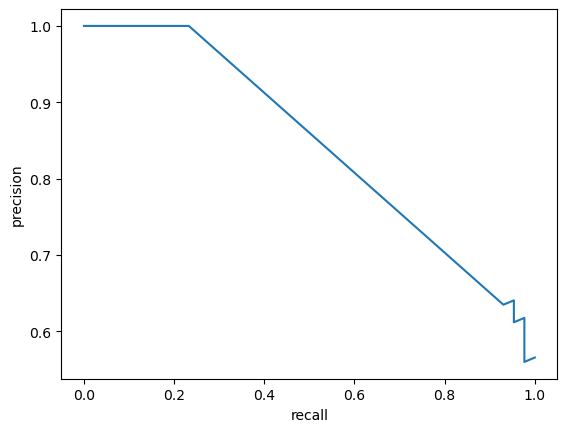

In [15]:
plt.plot(recall, precision)
plt.xlabel("recall")
plt.ylabel("precision")
plt.show()

In [16]:
f1

0.7663551401869159

## GNN Explainer

In [15]:
best_model

GraphSAGE(
  (conv1): SAGEConv(2, 8, aggr=mean)
  (conv2): SAGEConv(8, 16, aggr=mean)
  (lin1): Linear(in_features=16, out_features=8, bias=True)
  (lin2): Linear(in_features=8, out_features=2, bias=True)
  (loss_calc): CrossEntropyLoss()
  (torch_softmax): Softmax(dim=1)
)

In [16]:
from torch_geometric.explain import Explainer, ModelConfig
from torch_geometric.explain.algorithm import GNNExplainer

# Define the model configuration
model_config = ModelConfig(
    mode="binary_classification",  # Change this based on your task type
    task_level="node",  # Explaining node-level predictions
    return_type="raw",  # Adjust based on what your model returns
)

# Initialize the explainer with the required configuration
explainer = Explainer(
    model=best_model,
    algorithm=GNNExplainer(epochs=200),
    explanation_type='model',
    node_mask_type='attributes',  # Explains node features
    edge_mask_type='object',  # Explains edge importance
    model_config=model_config,  # Required argument
)

# Explain a specific node
node_idx = 7
explanation = explainer(x=G.x, edge_index=G.edge_index) 

# Extract feature and edge masks
node_feat_mask = explanation.node_mask
edge_mask = explanation.edge_mask

print("Size of explanation:", sum(edge_mask > 0))

TypeError: GraphSAGE.forward() takes 2 positional arguments but 3 were given